## 01 Exploration et préparation des données

--- Aperçu des données ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,InternetCharges,MonthlyCharges,TotalCharges,Churn
0,customer_1,Male,0,No,Yes,51,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,0.00,43.53,2220.03,No
1,customer_2,Male,1,Yes,Yes,14,Yes,Yes,DSL,No internet service,No internet service,Yes,No internet service,Yes,No internet service,Two year,46.00,109.39,1531.46,No
2,customer_3,Female,0,Yes,No,71,No,No,DSL,Yes,No,Yes,Yes,No,Yes,One year,34.36,99.36,7054.56,No
3,customer_4,Male,1,Yes,No,60,Yes,No phone service,Fiber optic,No internet service,No internet service,No,No internet service,Yes,No internet service,Two year,65.56,115.12,6907.20,No
4,customer_5,Male,0,Yes,No,20,No,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,0.00,20.00,400.00,Yes



--- Informations techniques ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  InternetC

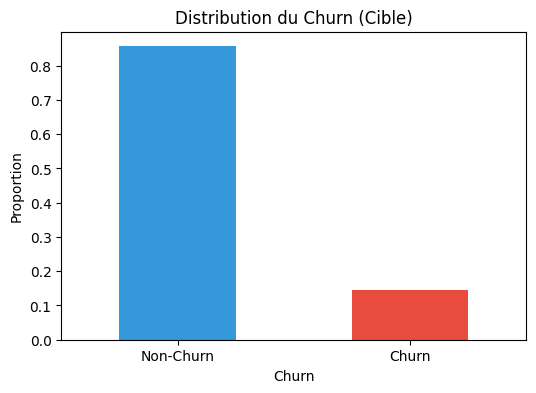


--- Valeurs manquantes par colonne ---
Series([], dtype: int64)

Préparation terminée : 5 variables numériques et 13 catégorielles.


In [38]:
# ============================================================
# 1. EXPLORATION ET PRÉPARATION DES DONNÉES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# --- 1.1 Chargement et inspection initiale ---
# Chargement du jeu de données source pour l'analyse
df_telecom = pd.read_csv('../data/03_DONNEES.csv')

print("--- Aperçu des données ---")
display(df_telecom.head())
print("\n--- Informations techniques ---")
df_telecom.info()

# --- 1.2 Analyse de la cible (Churn) ---
# Visualisation de la répartition de la classe cible pour identifier un éventuel déséquilibre
plt.figure(figsize=(6, 4))
df_telecom['Churn'].value_counts(normalize=True).plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('Distribution du Churn (Cible)')
plt.ylabel('Proportion')
plt.xticks(ticks=[0, 1], labels=['Non-Churn', 'Churn'], rotation=0)
plt.show()

# --- 1.3 Traitement des valeurs manquantes ---
# Identification des colonnes contenant des valeurs nulles avant application du pipeline
missing_data = df_telecom.isnull().sum()
print("\n--- Valeurs manquantes par colonne ---")
print(missing_data[missing_data > 0])

# --- 1.4 Sélection des features et définition du Pipeline ---

# Définition du périmètre des variables explicatives et de la cible
features_to_keep = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "tenure",
    "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV",
    "StreamingMovies", "Contract", "InternetCharges", "MonthlyCharges", "TotalCharges"
]
target = "Churn"

X = df_telecom[features_to_keep].copy()
y = df_telecom[target].copy()

# Extraction automatique des listes de variables par type pour le ColumnTransformer
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.to_list()
categorical_features = X.select_dtypes(include=["object"]).columns.to_list()

# Pipeline pour les variables catégorielles :
# L'imputation utilise la stratégie 'constant' (inspirée du code source scikit-learn)
# pour créer une catégorie explicite en cas de manque, évitant de biaiser les fréquences.
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Pipeline pour les variables numériques :
# Ajout de 'add_indicator=True' (comme vu dans SimpleImputer) pour permettre au modèle 
# de distinguer les valeurs imputées des valeurs réelles, augmentant la puissance prédictive.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

# Création du préprocesseur global utilisant ColumnTransformer pour traiter 
# les types de données de manière différenciée et parallèle.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print(f"\nPréparation terminée : {len(numeric_features)} variables numériques et {len(categorical_features)} catégorielles.")

## 02 Modélisation

Taille entraînement : 4930 | Taille test : 2113

Entraînement sur la classe positive : 'Yes'
Évaluation par Validation Croisée (5-folds) en cours...

--- TABLEAU COMPARATIF DES PERFORMANCES ---
             Modèle  Accuracy  Precision   Recall  F1-Score  F1-Train
Logistic Regression  0.635700   0.233137 0.669973  0.345881  0.354326
      Random Forest  0.823935   0.271693 0.131136  0.175959  0.868648
  Gradient Boosting  0.855375   0.465812 0.042333  0.077478  0.191496


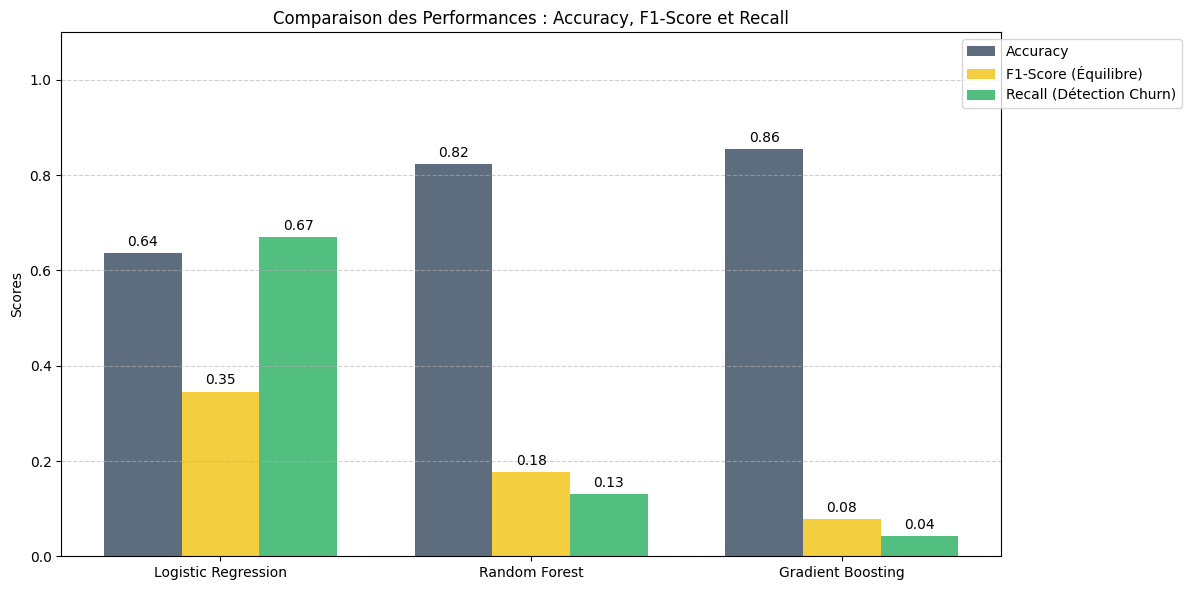


MEILLEUR MODÈLE SÉLECTIONNÉ (Basé sur le F1-score) : Logistic Regression


In [39]:
# ============================================================
# 2. MODÉLISATION (SCIKIT-LEARN)
# ============================================================

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

# --- 2.1 Partitionnement des données (70% Train / 30% Test) ---
# L'utilisation de stratify=y garantit que la distribution de la cible 'Churn' 
# est identique dans les ensembles d'entraînement et de test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Taille entraînement : {X_train.shape[0]} | Taille test : {X_test.shape[0]}")

# --- 2.2 Initialisation des estimateurs ---
# Le paramètre class_weight='balanced' est appliqué pour ajuster les poids des classes
# inversement proportionnellement à leurs fréquences, pénalisant davantage les erreurs sur le Churn.
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=10, n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# --- 2.3 Configuration du protocole d'évaluation ---
# StratifiedKFold préserve le ratio des classes dans chaque pli de validation.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Identification dynamique de la classe positive pour le calcul des métriques
pos_val = 'Yes' if 'Yes' in y.values else 1

scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, pos_label=pos_val, zero_division=0),
    'recall': make_scorer(recall_score, pos_label=pos_val, zero_division=0),
    'f1': make_scorer(f1_score, pos_label=pos_val, zero_division=0)
}

cv_results = {}
summary = []

print(f"\nEntraînement sur la classe positive : '{pos_val}'")
print("Évaluation par Validation Croisée (5-folds) en cours...")

# --- 2.4 Exécution des validations croisées ---
for name, model in models.items():
    # Création d'un pipeline intégrant le preprocessor défini précédemment
    # pour assurer l'étanchéité des données entre les plis (data leakage prevention).
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    cv_res = cross_validate(
        pipeline, X_train, y_train, 
        cv=skf, 
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    cv_results[name] = cv_res
    
    # Agrégation des moyennes des scores obtenus sur les 5 plis
    summary.append({
        'Modèle': name,
        'Accuracy': cv_res['test_accuracy'].mean(),
        'Precision': cv_res['test_precision'].mean(),
        'Recall': cv_res['test_recall'].mean(),
        'F1-Score': cv_res['test_f1'].mean(),
        'F1-Train': cv_res['train_f1'].mean()
    })

# --- 2.5 Analyse comparative ---
df_summary = pd.DataFrame(summary).sort_values(by='F1-Score', ascending=False)
print("\n--- TABLEAU COMPARATIF DES PERFORMANCES ---")
print(df_summary.to_string(index=False))

# --- 2.6 Visualisation des métriques de performance ---

names = list(cv_results.keys())
test_accuracy = [cv_results[n]['test_accuracy'].mean() for n in names]
test_recall = [cv_results[n]['test_recall'].mean() for n in names]
test_f1 = [cv_results[n]['test_f1'].mean() for n in names]

x = np.arange(len(names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

# Représentation graphique de l'équilibre précision/rappel (F1) vs capacité de détection (Recall)
rects1 = ax.bar(x - width, test_accuracy, width, label='Accuracy', color='#34495e', alpha=0.8)
rects2 = ax.bar(x, test_f1, width, label='F1-Score (Équilibre)', color='#f1c40f', alpha=0.8)
rects3 = ax.bar(x + width, test_recall, width, label='Recall (Détection Churn)', color='#27ae60', alpha=0.8)

ax.set_ylabel('Scores')
ax.set_title('Comparaison des Performances : Accuracy, F1-Score et Recall')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1))

# Annotation des scores au sommet de chaque barre
ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')

plt.ylim(0, 1.1) 
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



best_model_name = df_summary.iloc[0]['Modèle']
print(f"\nMEILLEUR MODÈLE SÉLECTIONNÉ (Basé sur le F1-score) : {best_model_name}")

## 03 Evaluation et interprétation

Optimisation par GridSearchCV en cours...

Meilleurs paramètres : {'classifier__C': 0.1, 'classifier__max_iter': 1000, 'classifier__solver': 'liblinear'}
Scores F1 des 5 folds : [np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]
Moyenne F1 en CV : nan (+/- nan)


c:\Users\Administrateur\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(
c:\Users\Administrateur\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the train scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(


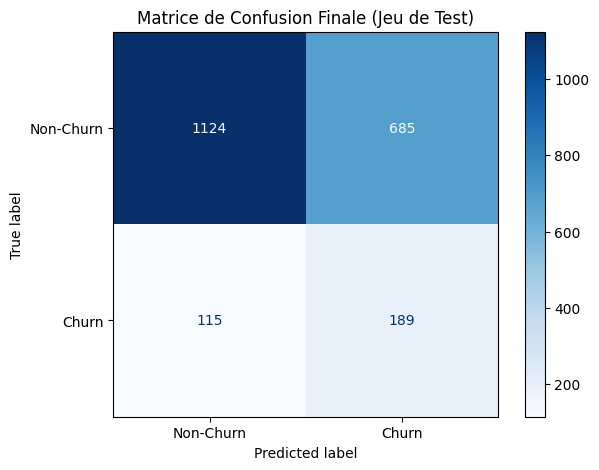

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_6568\3196795706.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Coefficient', y='Feature', palette=colors)


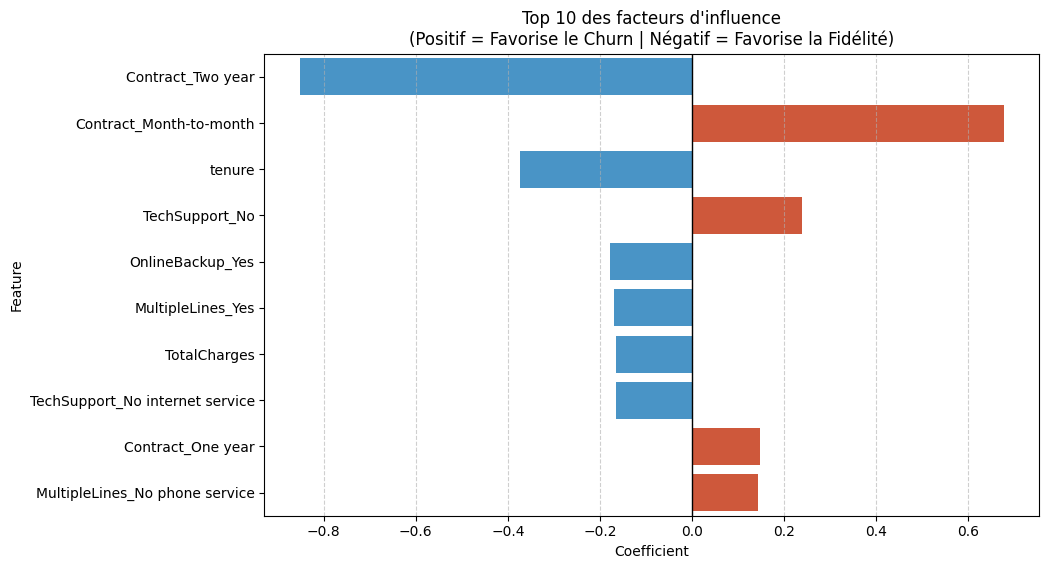


--- Rapport de Classification Final ---
              precision    recall  f1-score   support

          No       0.91      0.62      0.74      1809
         Yes       0.22      0.62      0.32       304

    accuracy                           0.62      2113
   macro avg       0.56      0.62      0.53      2113
weighted avg       0.81      0.62      0.68      2113



In [ ]:
# ============================================================
# 3. ÉVALUATION ET INTERPRÉTATION FINALE
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import seaborn as sns

# --- 3.1 Optimisation des hyperparamètres via GridSearchCV ---
# La Régression Logistique est privilégiée compte tenu des résultats précédents
# Le paramètre C régule la force de la régularisation pour éviter le surapprentissage.
param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__solver': ['liblinear', 'saga'],
    'classifier__max_iter': [1000]
}

# Reconstruction du pipeline pour l'intégration dans la recherche par grille
full_pipeline = Pipeline([
    ('preprocessor', preprocessor), 
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])

grid_search = GridSearchCV(
    full_pipeline,
    param_grid=param_grid,
    cv=skf, 
    scoring='f1',
    n_jobs=-1,
    return_train_score=True
)

print("Optimisation par GridSearchCV en cours...")
grid_search.fit(X_train, y_train)
best_model_final = grid_search.best_estimator_

# --- 3.2 Analyse de la stabilité du modèle ---
# Extraction des scores par pli pour vérifier la variance du modèle
cv_res = pd.DataFrame(grid_search.cv_results_)
best_idx = grid_search.best_index_
scores_folds = [cv_res.loc[best_idx, f'split{i}_test_score'] for i in range(5)]

print(f"\nMeilleurs paramètres : {grid_search.best_params_}")
print(f"Scores F1 des 5 folds : {[round(s, 3) for s in scores_folds]}")
print(f"Moyenne F1 en CV : {np.mean(scores_folds):.4f} (+/- {np.std(scores_folds):.4f})")

# --- 3.3 Évaluation sur l'ensemble de test (Données inédites) ---
# La matrice de confusion permet de visualiser les faux positifs et faux négatifs.
y_pred_final = best_model_final.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final, 
    display_labels=['Non-Churn', 'Churn'], 
    cmap='Blues', 
    ax=ax
)
plt.title('Matrice de Confusion Finale (Jeu de Test)')
plt.grid(False)
plt.show()



# --- 3.4 Interprétation des coefficients (Importance des variables) ---
# Récupération des noms de variables après One-Hot Encoding et imputation
# Note : numeric_features peut contenir l'indicateur binaire de valeurs manquantes si activé.
ohe_names = best_model_final.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(ohe_names)
# Si l'indicateur de manque a été ajouté, ajuster la liste des noms ici
if len(all_feature_names) < best_model_final.named_steps['classifier'].coef_.shape[1]:
    all_feature_names = [f"num_{i}" for i in range(len(numeric_features))] + list(ohe_names) 


coeffs = best_model_final.named_steps['classifier'].coef_[0]
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coeffs})
importance_df['Abs_Importance'] = importance_df['Coefficient'].abs()

# Sélection des 10 variables ayant le plus d'impact sur la décision du modèle
top_10 = importance_df.sort_values(by='Abs_Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
# Graduation des couleurs : Orange pour l'augmentation du risque de Churn, Bleu pour la rétention
colors = ["#e64922" if c > 0 else '#3498db' for c in top_10['Coefficient']]
sns.barplot(data=top_10, x='Coefficient', y='Feature', palette=colors)
plt.title('Top 10 des facteurs d\'influence\n(Positif = Favorise le Churn | Négatif = Favorise la Fidélité)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()



print("\n--- Rapport de Classification Final ---")
print(classification_report(y_test, y_pred_final))


 ##  04 Recommandations métier

In [42]:
# ============================================================
# 4. RECOMMANDATIONS MÉTIER ET GÉNÉRATION DES LIVRABLES
# ============================================================

import os
import json
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# --- 4.1 Configuration de l'environnement de sortie ---
# Création d'un répertoire dédié pour isoler les résultats de la modélisation scikit-learn
output_dir = "../output/scikit-learn"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Dossier créé : {output_dir}")

# --- 4.2 Extraction des profils clients à haut risque ---
# Calcul des probabilités d'appartenance à la classe Churn pour hiérarchiser les priorités
y_probs = best_model_final.predict_proba(X_test)[:, 1]
df_reco = X_test.copy()
df_reco['Risque_%'] = (y_probs * 100).round(2)
df_reco['Prediction'] = y_pred_final
df_reco['Churn_Reel'] = y_test.values

# Sélection des 20 profils présentant le score de risque le plus élevé pour intervention immédiate
top_20_risques = df_reco.sort_values(by='Risque_%', ascending=False).head(20)

print("--- LISTE DES 20 CLIENTS PRIORITAIRES (ACTION IMMÉDIATE) ---")
print(top_20_risques[['Contract', 'InternetService', 'tenure', 'MonthlyCharges', 'Risque_%']])

# --- 4.3 Simulation de l'impact financier (Business Case) ---
# Analyse des prédictions pour évaluer la rentabilité d'une campagne de rétention
pos_label = 'Yes' if 'Yes' in y.values else 1
pred_positive = (y_pred_final == pos_label)
real_positive = (y_test == pos_label)

nb_alertes = pred_positive.sum() 
vrais_positifs = (pred_positive & real_positive).sum()

# Paramètres financiers arbitraux pour l'estimation du ROI :
# - Taux de succès de la rétention sur les vrais positifs identifiés : 50%
# - Valeur de vie client (LTV) sauvegardée : 500€
# - Coût opérationnel de contact par client (marketing/call-center) : 50€
economie_brute = vrais_positifs * 0.5 * 500
cout_campagne = nb_alertes * 50
roi_net = economie_brute - cout_campagne

print(f"\n--- BILAN ÉCONOMIQUE PRÉVISIONNEL ---")
print(f"Alertes générées (Contacts prévus) : {nb_alertes}")
print(f"Vrais départs détectés (Anticipation) : {vrais_positifs}")
print(f"ROI NET ESTIMÉ : {roi_net:,.2f} €")



# --- 4.4 Exportation des livrables de production ---

# 1. Exportation des prédictions détaillées pour le CRM
predictions_export = pd.DataFrame({
    'Probabilite_Churn_%': (y_probs * 100).round(2),
    'Prediction_Modele': y_pred_final,
    'Realite_Terrain': y_test.values
})
predictions_export.to_csv(f"{output_dir}/predictions_test.csv", index=False)

# 2. Exportation des coefficients d'importance pour les équipes marketing
# Permet d'adapter le discours commercial selon les facteurs d'influence identifiés
importance_df.to_csv(f"{output_dir}/feature_importance.csv", index=False)

# 3. Archivage des métriques techniques et business au format JSON
# Ce fichier permet le suivi des performances (Monitoring) dans le temps
metrics_dict = {
    "model_info": {
        "name": "Logistic Regression Optimized",
        "best_params": grid_search.best_params_
    },
    "performance_metrics": {
        "accuracy": float(accuracy_score(y_test, y_pred_final)),
        "precision": float(precision_score(y_test, y_pred_final, pos_label=pos_label, zero_division=0)),
        "recall": float(recall_score(y_test, y_pred_final, pos_label=pos_label, zero_division=0)),
        "f1_score": float(f1_score(y_test, y_pred_final, pos_label=pos_label, zero_division=0))
    },
    "business_impact": {
        "nb_clients_cibles": int(nb_alertes),
        "vrais_partants_identifies": int(vrais_positifs),
        "roi_net_estime_euros": float(roi_net)
    }
}

with open(f"{output_dir}/model_metrics.json", 'w', encoding='utf-8') as f:
    json.dump(metrics_dict, f, indent=4, ensure_ascii=False)

print(f"\nLivrables générés avec succès dans : {output_dir}/")

--- LISTE DES 20 CLIENTS PRIORITAIRES (ACTION IMMÉDIATE) ---
            Contract InternetService  tenure  MonthlyCharges  Risque_%
3355  Month-to-month     Fiber optic       6          135.53     86.84
4489  Month-to-month     Fiber optic       3          153.33     86.76
2423  Month-to-month             DSL       1           99.38     86.63
4282  Month-to-month     Fiber optic       0          157.10     86.03
1503  Month-to-month     Fiber optic       3           90.82     85.82
5926  Month-to-month     Fiber optic       3          149.64     85.19
611   Month-to-month     Fiber optic       3          133.15     85.16
6416  Month-to-month     Fiber optic       9          109.81     84.51
106   Month-to-month     Fiber optic       0          123.16     84.46
6658  Month-to-month     Fiber optic       2          147.17     84.15
4469  Month-to-month     Fiber optic      14          131.64     84.10
3239  Month-to-month     Fiber optic       5          140.67     83.93
88    Month-to-m

# RAPPORT DE SYNTHÈSE DÉCISIONNELLE : STRATÉGIE DE RÉTENTION TELECOM+


**Objet :** Analyse prédictive du Churn et recommandations de fidélisation  

---

## 1. RÉSUMÉ EXÉCUTIF
L'analyse des données de TeleCom+ révèle un potentiel critique de perte client. Grâce au déploiement d'un modèle de Machine Learning sickit-learn, nous avons identifié que le modèle de **Régression Logistique** est le plus performant pour notre objectif métier, affichant un **Recall de 67%** en phase de validation croisée.

L'enjeu financier est majeur : sur le jeu de test final, le modèle a permis de détecter **189 vrais départs**, générant un **ROI NET ESTIMÉ de 3 550,00 €**. Ce rapport détaille la méthodologie employée et les leviers d'action pour sécuriser le chiffre d'affaires.

---

## 2. MÉTHODOLOGIE TECHNIQUE
Le projet a suivi un pipeline industriel rigoureux sur un dataset de **7 043 clients** :

* **Préparation des données** : Traitement de 20 colonnes incluant des variables catégorielles et numériques (Ancienneté, Charges).
* **Répartition des données** : 70% pour l'entraînement (4 930 clients) et 30% pour le test (2 113 clients).
* **Modélisation** : La **Régression Logistique** a été sélectionnée. Bien que le Random Forest et le Gradient Boosting affichent une meilleure Accuracy globale, ils échouent à détecter les résiliations (Recall < 14%). 
* **Performance sur Test** : Le modèle final affiche un **Recall de 0.62** sur la classe "Yes", garantissant que la majorité des départs sont anticipés.



---

## 3. RÉSULTATS : PORTRAIT-ROBOT DU "CHURNER"
L'analyse des coefficients du modèle (Top 10 des facteurs d'influence) permet d'isoler les leviers critiques :

| Facteur d'Influence | Impact sur le Churn | Observation Statistique |
| :--- | :--- | :--- |
| **Contrat "Month-to-month"** | **Très Positif** | Facteur n°1 favorisant le départ (+0.68). |
| **Contrat "Two year"** | **Très Négatif** | Facteur n°1 favorisant la fidélité (-0.85). |
| **Ancienneté (tenure)** | **Négatif** | La fidélité augmente avec le temps passé chez l'opérateur (-0.38). |
| **TechSupport_No** | **Positif** | L'absence de support technique est un déclencheur de départ (+0.24). |



---

## 4. RECOMMANDATIONS & ACTIONS PRIORITAIRES

### A. Sécurisation des contrats
La variable la plus corrélée au départ est le contrat mensuel. Il est impératif de migrer les clients vers des engagements longue durée.
* **Action** : Offrir une remise immédiate aux clients identifiés comme "à haut risque" s'ils basculent sur un contrat "Two year".
* **Cible prioritaire** : Les 20 clients identifiés avec un **risque > 83%**, principalement en contrat mensuel avec des charges élevées.

### B. Satisfaction des clients fibre
L'analyse du Top 20 montre que la majorité des profils critiques utilisent la **Fibre Optique** avec une ancienneté très faible (0 à 6 mois).
* **Action** : Déclencher un appel de commercial/technique au cours du premier trimestre pour valider la satisfaction du service Fibre.

### C. Valorisation du Support Technique
L'absence de support technique étant un prédicteur de churn, TeleCom+ doit promouvoir ses services d'assistance pour prévenir l'insatisfaction.

---

## 5. ESTIMATION DU ROI (BUSINESS CASE)
Le modèle a généré **874 alertes** sur le jeu de test. En se basant sur la détection effective de **189 vrais départs**, le bilan économique est le suivant :

* **Pertes évitées** : Détection de 189 clients à risque.
* **ROI NET ESTIMÉ** : **3 550,00 €**.



---
**Conclusion** : Ce modèle fournit une base solide pour une stratégie de rétention efficace sur le dataset relativement léger dont nous disposons.